In [86]:
from __future__ import annotations
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons, make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, recall_score
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import pandas as pd
import sys

sys.path.append('..')
from evaluation_functions import print_metrics, plot_decision_boundary, plot_roc, plot_confusion_matrix, measure_fit_time, ClassifierAbstraction

# Preparing synthetic data

In [87]:
RANDOM_STATE = 264034
N_SAMPLES = 2634

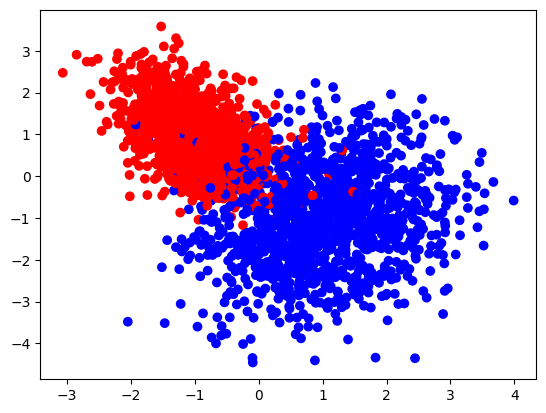

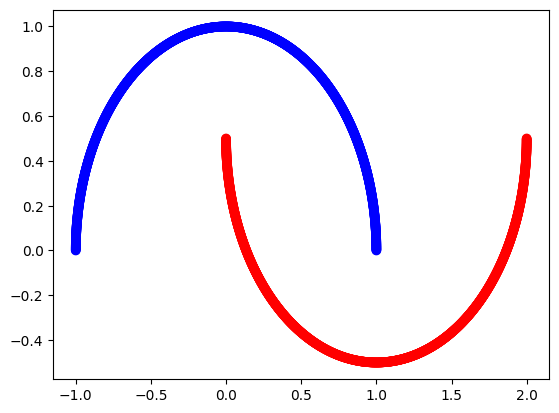

In [88]:
X_classification, y_classification = make_classification(n_samples = N_SAMPLES, n_clusters_per_class=1, n_features = 2, n_redundant = 0, n_informative = 2, random_state = RANDOM_STATE)
X_moons, y_moons = make_moons(n_samples = N_SAMPLES, random_state = RANDOM_STATE, noise=0)

plt.scatter(X_classification[:, 0], X_classification[:, 1], c=y_classification, cmap="bwr")
plt.show()
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="bwr")
plt.show()

________

# Implementation of neuron

## Activation functions

In [89]:
def heaviside(s):
    return np.where(s >= 0, 1, 0)

def heaviside_derivative(s):
    return 1

def sigmoid(s):
    return 1/(1+np.exp(-s))

def sigmoid_derivative(s):
    return (np.exp(-s)/(1+np.exp(-s))**2)

def sin(s):
    return np.sin(s)

def sin_derivative(s):
    return np.cos(s)

def tanh(s):
    return np.tanh(s)

def tanh_derivative(s):
    return 1 - np.tanh(s)**2

def sign(s):
    return np.sign(s)

def sign_derivative(s):
    return 1

def relu(s):
    return np.maximum(0, s)

def relu_derivative(s):
    return np.where(s >= 0, 1.0, 0.0)

def leaky_relu(s):
    return np.where(s > 0, s, 0.01 * s)

def leaky_relu_derivative(s):
    return np.where(s > 0, 1.0, 0.01)

## Neuron

In [90]:
class Neuron():
    def __init__(self, num_inputs, activ_func, deriv_func) -> None:
        if activ_func == relu:
            self.weights = np.random.randn(num_inputs) * np.sqrt(2 / num_inputs)
            self.bias = 0.01
        else:
            self.weights = np.random.randn(num_inputs) * 0.1
            self.bias = np.random.randn()
        self.activation = activ_func
        self.derivative = deriv_func

    def predict(self, X):
        s = X @ self.weights + self.bias
        y = self.activation(s)

        if self.activation in [sigmoid, relu, leaky_relu]:
            return (y >= 0.5).astype(int)

        elif self.activation in [tanh, sign, sin]:
            return (y >= 0).astype(int)
        
        else:  # heaviside
            return y.astype(int)

    def decision_boundary(self, X):
        return self.activation(X @ self.weights + self.bias)
    
    def cosine_learning_rate(self, n, n_max, eta_min, eta_max):
        return eta_min + (eta_max - eta_min) * (1 + np.cos(np.pi * n / n_max))/2

    def train(self, X, y, epoch, n_max, eta_min, eta_max, batch_size=1):
        learning_rate = self.cosine_learning_rate(epoch, n_max, eta_min, eta_max)

        n_samples = X.shape[0]

        for batch_start in range(0, n_samples, batch_size):
            X_batch = X[batch_start: batch_start + batch_size]
            y_batch = y[batch_start: batch_start + batch_size]

            delta_weights = np.zeros_like(self.weights)
            delta_bias = 0.0

            for i in range(len(X_batch)):
                x = X_batch[i]
                d = y_batch[i]

                s = np.dot(self.weights.T, x) + self.bias
                y_pred = self.activation(s)

                epsilon = d - y_pred

                delta_weights += epsilon * self.derivative(s) * x
                delta_bias += epsilon * self.derivative(s)

            n = len(X_batch)

            self.weights += learning_rate * delta_weights / n
            self.bias    += learning_rate * delta_bias / n

## Remapping to match activation func

In [91]:
LABEL_MAP = {
    sigmoid:    lambda d: float(d),          # output in (0, 1) → keep {0, 1}
    heaviside:  lambda d: float(d),          # output in {0, 1}
    tanh:       lambda d: 2.0 * d - 1.0,    # output in (-1, 1) → remap {0,1}→{-1,1}
    sign:       lambda d: 2.0 * d - 1.0,    # output in {-1, 1}
    sin:        lambda d: 2.0 * d - 1.0,    # output in (-1, 1)
    relu:       lambda d: float(d),          # unbounded, keep as-is
    leaky_relu: lambda d: float(d),
}
 
def adjust_labels(X, y, activ_func):
    remap = LABEL_MAP.get(activ_func, lambda d: float(d))
    y_new = np.array([remap(d) for d in y])
    return X, y_new

______

# Testing on synthetic dataset

In [ ]:
import time  # add at the top of your script if not already present

def run_experiment_block(X, y, title):
    print(f"\n===== {title} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
    )

    activations = [
        (sigmoid, sigmoid_derivative),
        (heaviside, heaviside_derivative),
        (tanh, tanh_derivative),
        (sign, sign_derivative),
        (sin, sin_derivative),
        (relu, relu_derivative),
        (leaky_relu, leaky_relu_derivative),
    ]

    EPOCHS = 100

    for activ, deriv in activations:
        print(f"\n--- Activation: {activ.__name__} ---")

        X_train_adj, y_train_adj = adjust_labels(X_train, y_train, activ)

        neuron_sgd = Neuron(2, activ, deriv)
        neuron_batch = Neuron(2, activ, deriv)

        # ---------- Train SGD (batch_size=1) ----------
        print("\nTraining SGD...")
        start_time = time.perf_counter()
        for epoch in range(EPOCHS):
            perm = np.random.permutation(len(X_train_adj))
            X_shuffled = X_train_adj[perm]
            y_shuffled = y_train_adj[perm]

            neuron_sgd.train(
                X_shuffled, y_shuffled,
                epoch=epoch,
                n_max=EPOCHS,
                eta_min=0.001,
                eta_max=0.1,
                batch_size=1
            )
        end_time = time.perf_counter()
        sgd_time = end_time - start_time
        print(f"SGD training time: {sgd_time:.4f} seconds")

        # ---------- Train Mini‑Batch (batch_size=32) ----------
        print("\nTraining Mini‑Batch...")
        start_time = time.perf_counter()
        for epoch in range(EPOCHS):
            perm = np.random.permutation(len(X_train_adj))
            X_shuffled = X_train_adj[perm]
            y_shuffled = y_train_adj[perm]

            neuron_batch.train(
                X_shuffled, y_shuffled,
                epoch=epoch,
                n_max=EPOCHS,
                eta_min=0.001,
                eta_max=0.1,
                batch_size=32
            )
        end_time = time.perf_counter()
        batch_time = end_time - start_time
        print(f"Mini‑Batch training time: {batch_time:.4f} seconds")

        # ---- Evaluation ----
        print("\nSGD:")
        print_metrics(neuron_sgd, X_test, y_test, f"{activ.__name__} SGD")

        print("\nBatch:")
        print_metrics(neuron_batch, X_test, y_test, f"{activ.__name__} Batch")

        # ---- Decision boundaries ----
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        plot_decision_boundary(
            neuron_sgd, X_test, y_test,
            axes[0], f"{activ.__name__} SGD"
        )
        plot_decision_boundary(
            neuron_batch, X_test, y_test,
            axes[1], f"{activ.__name__} Batch"
        )
        plt.show()

        # ---- Confusion matrices ----
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        plot_confusion_matrix(
            neuron_sgd, X_test, y_test,
            axes[0], title=f"{activ.__name__} SGD"
        )
        plot_confusion_matrix(
            neuron_batch, X_test, y_test,
            axes[1], title=f"{activ.__name__} Batch"
        )
        plt.show()

## Classification dataset


===== CLASSIFICATION DATASET =====

--- Activation: sigmoid ---

Training SGD...
SGD training time: 1.3519 seconds

Training Mini‑Batch...
Mini‑Batch training time: 0.6871 seconds

SGD:

── sigmoid SGD ──
Confusion matrix:
[[366  30]
 [ 12 383]]
Accuracy:       0.9469026548672567
Recall:         0.9696202531645569
Specificity:    0.9242424242424242

Batch:

── sigmoid Batch ──
Confusion matrix:
[[365  31]
 [ 10 385]]
Accuracy:       0.9481668773704172
Recall:         0.9746835443037974
Specificity:    0.9217171717171717


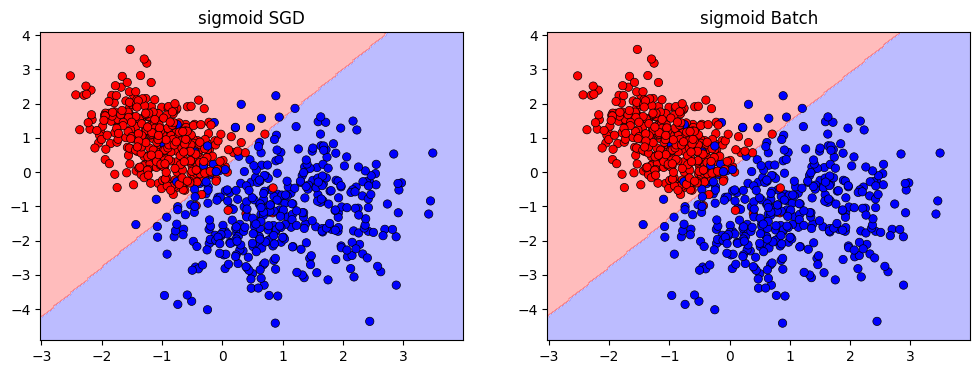

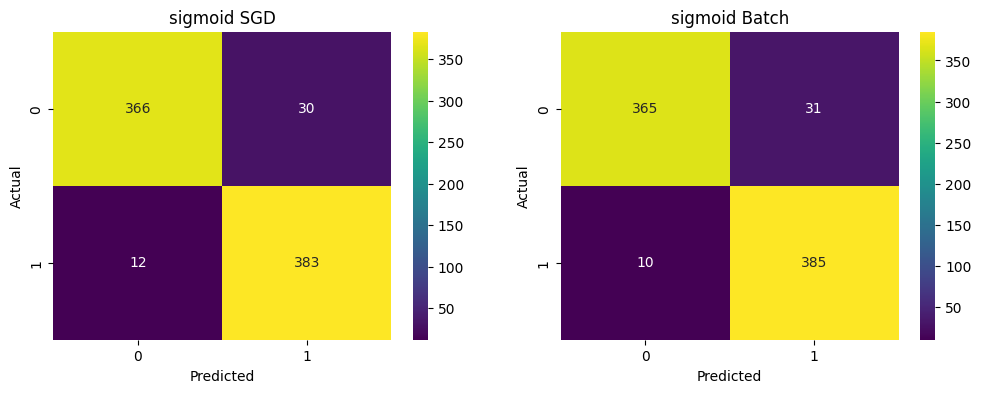


--- Activation: heaviside ---

Training SGD...
SGD training time: 1.5531 seconds

Training Mini‑Batch...
Mini‑Batch training time: 0.8315 seconds

SGD:

── heaviside SGD ──
Confusion matrix:
[[382  14]
 [ 65 330]]
Accuracy:       0.900126422250316
Recall:         0.8354430379746836
Specificity:    0.9646464646464646

Batch:

── heaviside Batch ──
Confusion matrix:
[[361  35]
 [  9 386]]
Accuracy:       0.9443742098609356
Recall:         0.9772151898734177
Specificity:    0.9116161616161617


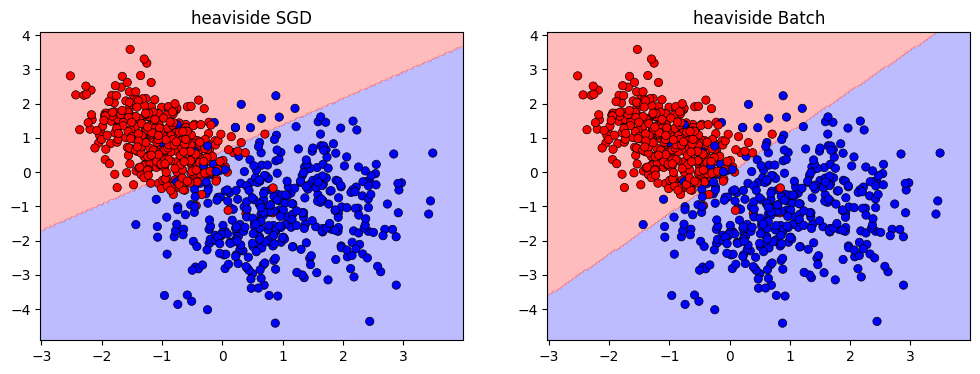

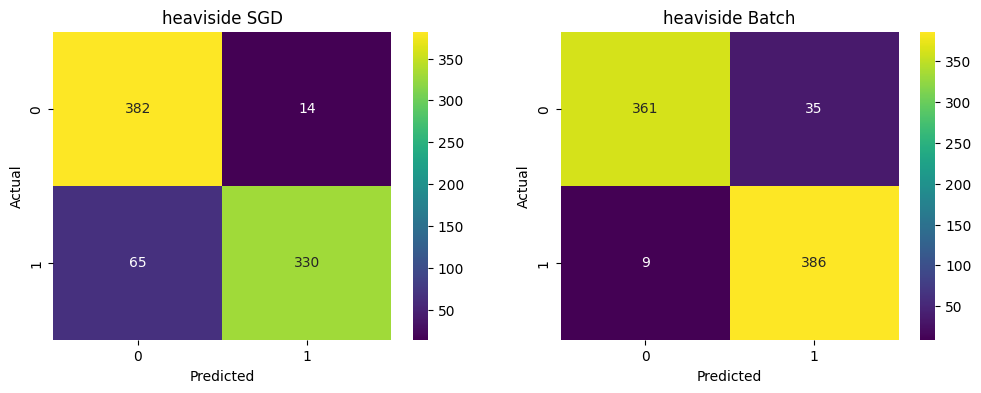


--- Activation: tanh ---

Training SGD...
SGD training time: 1.3024 seconds

Training Mini‑Batch...
Mini‑Batch training time: 0.5714 seconds

SGD:

── tanh SGD ──
Confusion matrix:
[[366  30]
 [ 12 383]]
Accuracy:       0.9469026548672567
Recall:         0.9696202531645569
Specificity:    0.9242424242424242

Batch:

── tanh Batch ──
Confusion matrix:
[[366  30]
 [ 12 383]]
Accuracy:       0.9469026548672567
Recall:         0.9696202531645569
Specificity:    0.9242424242424242


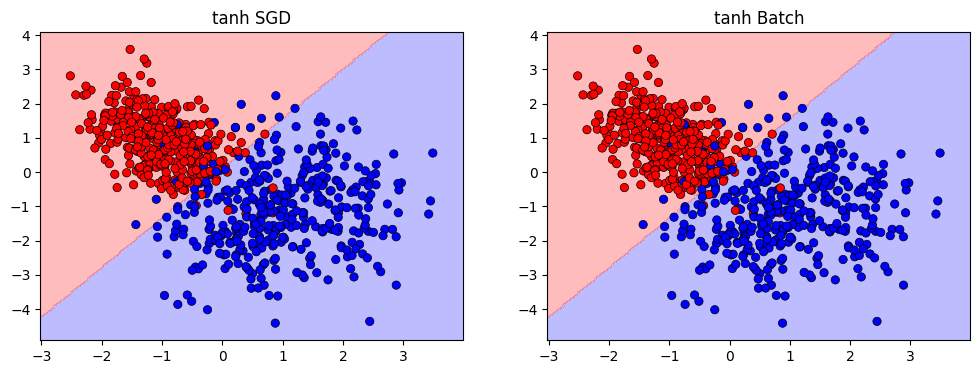

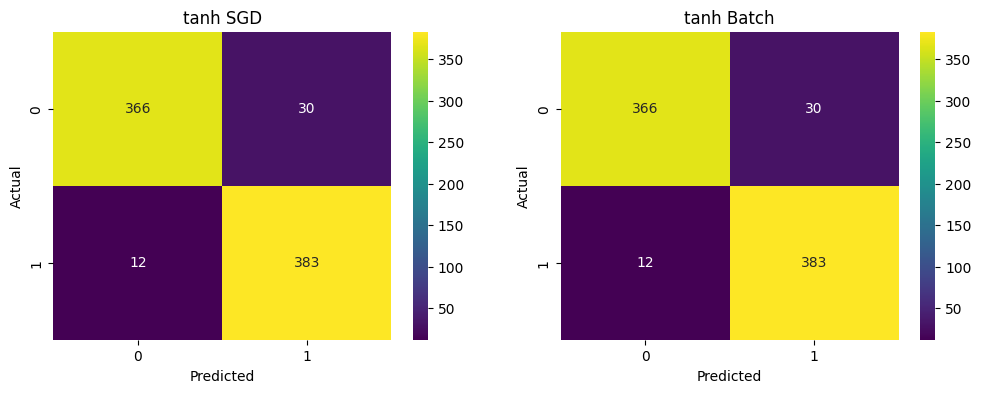


--- Activation: sign ---

Training SGD...
SGD training time: 1.1214 seconds

Training Mini‑Batch...
Mini‑Batch training time: 0.4734 seconds

SGD:

── sign SGD ──
Confusion matrix:
[[346  50]
 [  6 389]]
Accuracy:       0.9292035398230089
Recall:         0.9848101265822785
Specificity:    0.8737373737373737

Batch:

── sign Batch ──
Confusion matrix:
[[361  35]
 [ 11 384]]
Accuracy:       0.9418457648546145
Recall:         0.9721518987341772
Specificity:    0.9116161616161617


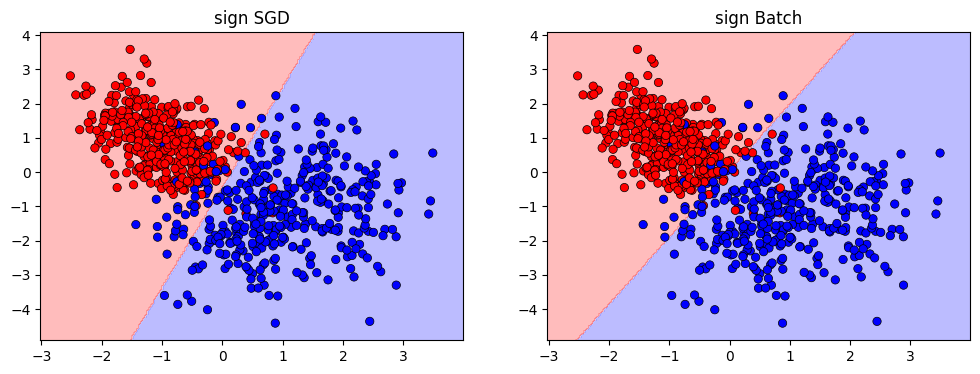

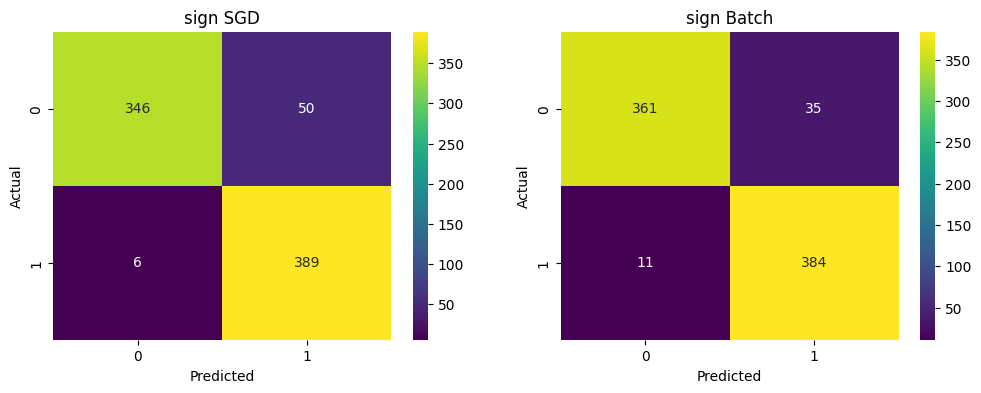


--- Activation: sin ---

Training SGD...
SGD training time: 1.0960 seconds

Training Mini‑Batch...
Mini‑Batch training time: 0.4948 seconds

SGD:

── sin SGD ──
Confusion matrix:
[[361  35]
 [ 10 385]]
Accuracy:       0.943109987357775
Recall:         0.9746835443037974
Specificity:    0.9116161616161617

Batch:

── sin Batch ──
Confusion matrix:
[[360  36]
 [ 10 385]]
Accuracy:       0.9418457648546145
Recall:         0.9746835443037974
Specificity:    0.9090909090909091


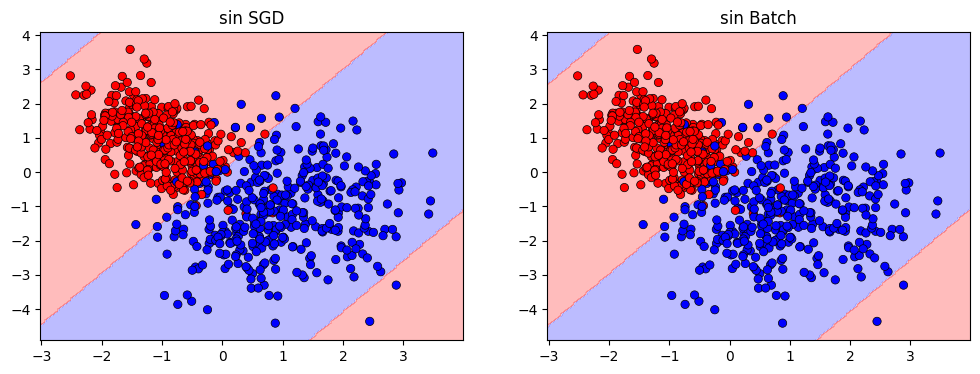

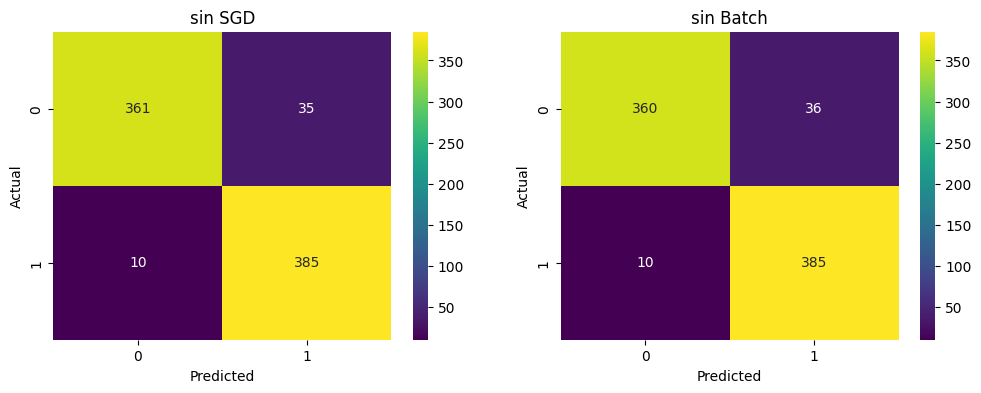


--- Activation: relu ---

Training SGD...
SGD training time: 2.0450 seconds

Training Mini‑Batch...
Mini‑Batch training time: 1.4285 seconds

SGD:

── relu SGD ──
Confusion matrix:
[[375  21]
 [ 18 377]]
Accuracy:       0.9506953223767383
Recall:         0.9544303797468354
Specificity:    0.946969696969697

Batch:

── relu Batch ──
Confusion matrix:
[[396   0]
 [395   0]]
Accuracy:       0.5006321112515802
Recall:         0.0
Specificity:    1.0


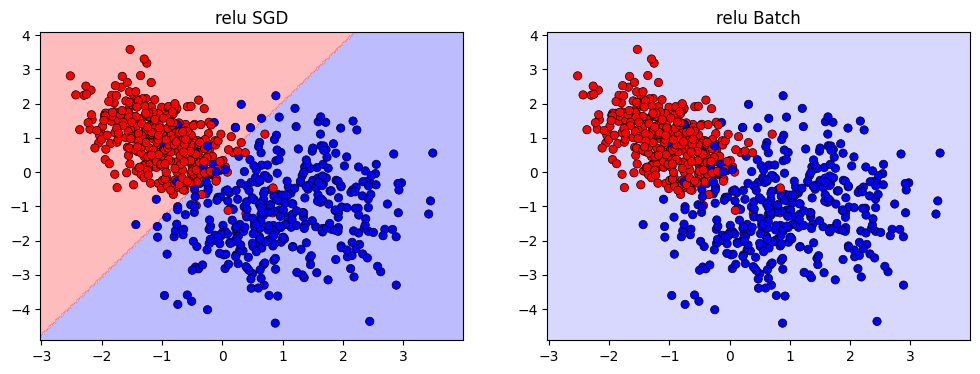

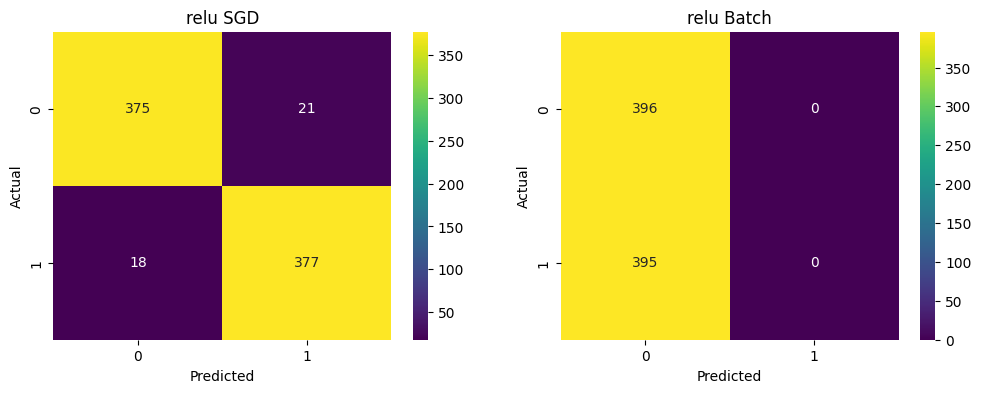


--- Activation: leaky_relu ---

Training SGD...
SGD training time: 2.2120 seconds

Training Mini‑Batch...
Mini‑Batch training time: 1.5083 seconds

SGD:

── leaky_relu SGD ──
Confusion matrix:
[[374  22]
 [ 15 380]]
Accuracy:       0.9532237673830595
Recall:         0.9620253164556962
Specificity:    0.9444444444444444

Batch:

── leaky_relu Batch ──
Confusion matrix:
[[375  21]
 [ 15 380]]
Accuracy:       0.95448798988622
Recall:         0.9620253164556962
Specificity:    0.946969696969697


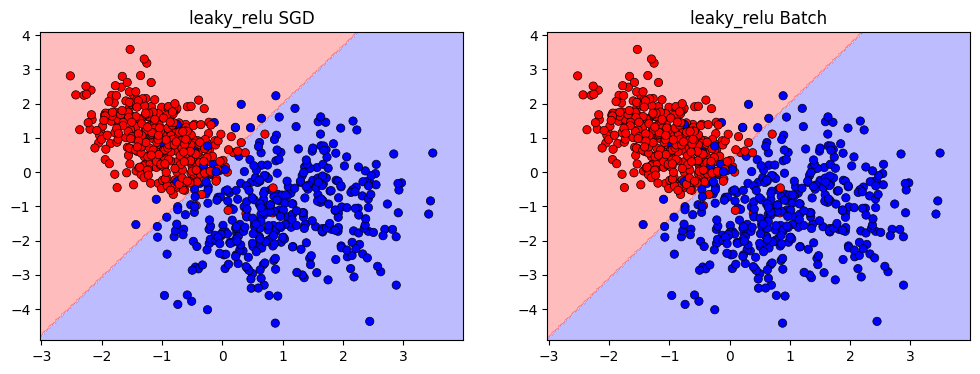

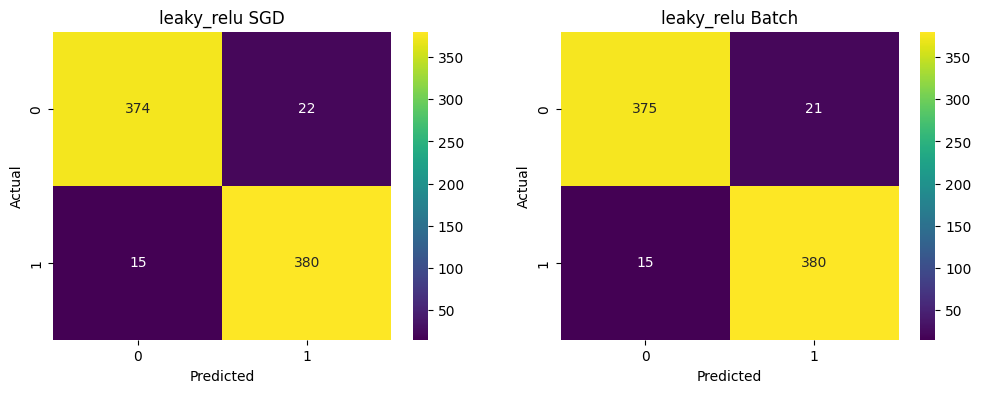

In [93]:
run_experiment_block(X_classification, y_classification, "CLASSIFICATION DATASET")

## Moons dataset


===== MOONS DATASET =====

--- Activation: sigmoid ---

Training SGD...
SGD training time: 1.3277 seconds

Training Mini‑Batch...
Mini‑Batch training time: 0.7041 seconds

SGD:

── sigmoid SGD ──
Confusion matrix:
[[354  42]
 [ 50 345]]
Accuracy:       0.8836915297092288
Recall:         0.8734177215189873
Specificity:    0.8939393939393939

Batch:

── sigmoid Batch ──
Confusion matrix:
[[349  47]
 [ 56 339]]
Accuracy:       0.8697850821744627
Recall:         0.8582278481012658
Specificity:    0.8813131313131313


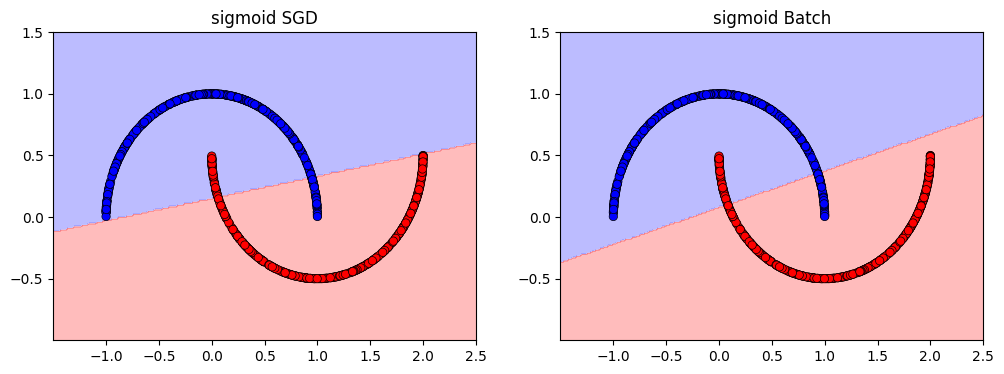

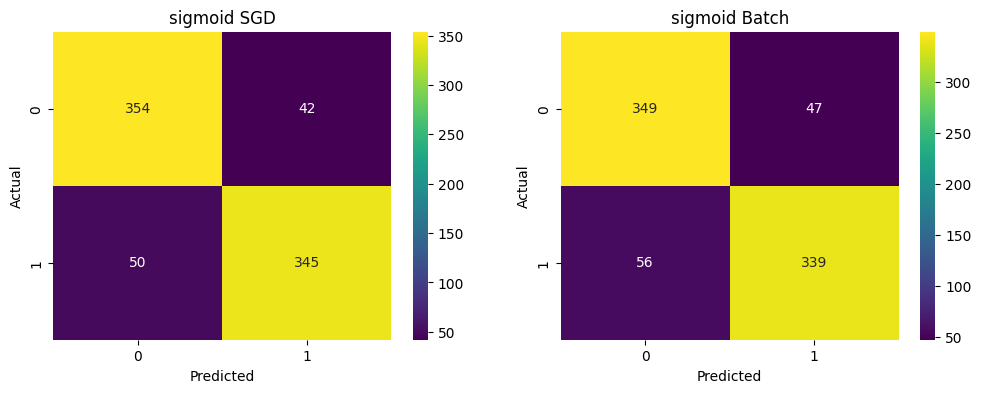


--- Activation: heaviside ---

Training SGD...
SGD training time: 1.4046 seconds

Training Mini‑Batch...
Mini‑Batch training time: 0.9753 seconds

SGD:

── heaviside SGD ──
Confusion matrix:
[[356  40]
 [ 62 333]]
Accuracy:       0.8710493046776233
Recall:         0.8430379746835444
Specificity:    0.898989898989899

Batch:

── heaviside Batch ──
Confusion matrix:
[[336  60]
 [ 37 358]]
Accuracy:       0.877370417193426
Recall:         0.9063291139240506
Specificity:    0.8484848484848485


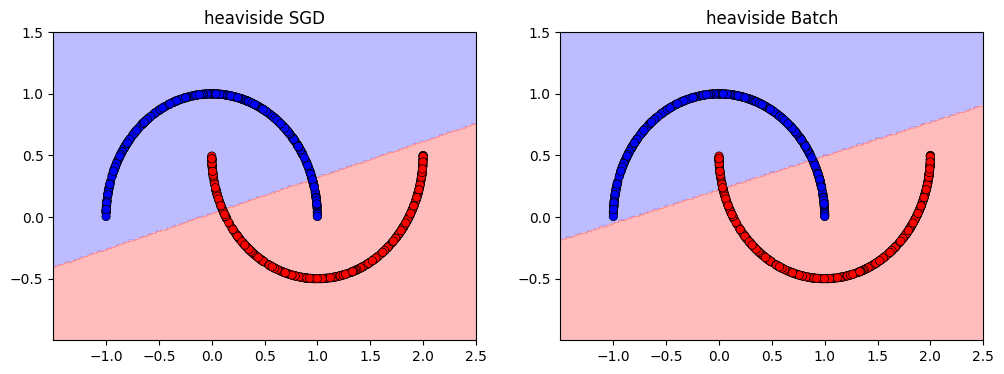

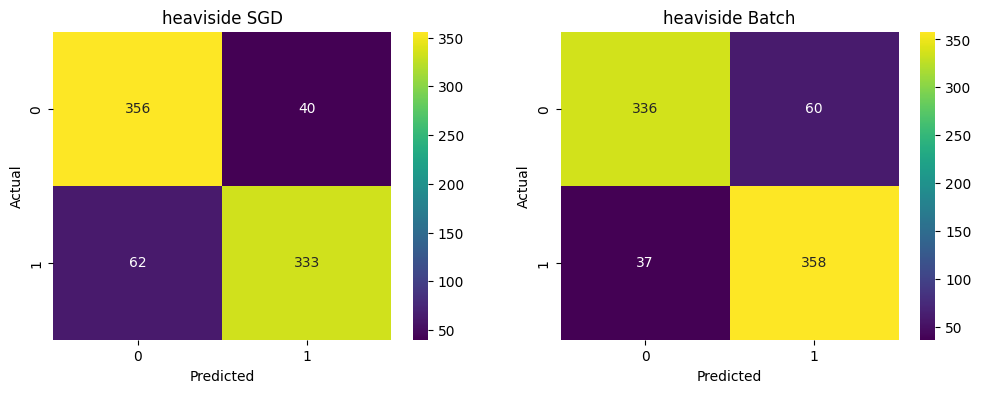


--- Activation: tanh ---

Training SGD...
SGD training time: 1.4003 seconds

Training Mini‑Batch...
Mini‑Batch training time: 0.5984 seconds

SGD:

── tanh SGD ──
Confusion matrix:
[[354  42]
 [ 50 345]]
Accuracy:       0.8836915297092288
Recall:         0.8734177215189873
Specificity:    0.8939393939393939

Batch:

── tanh Batch ──
Confusion matrix:
[[354  42]
 [ 50 345]]
Accuracy:       0.8836915297092288
Recall:         0.8734177215189873
Specificity:    0.8939393939393939


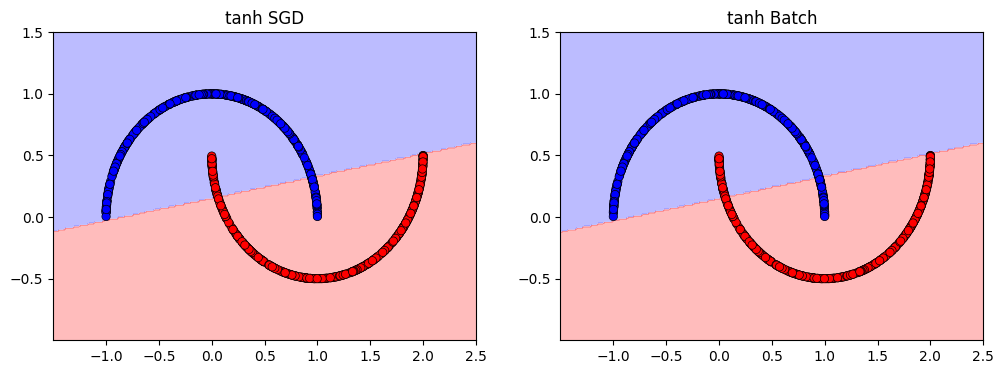

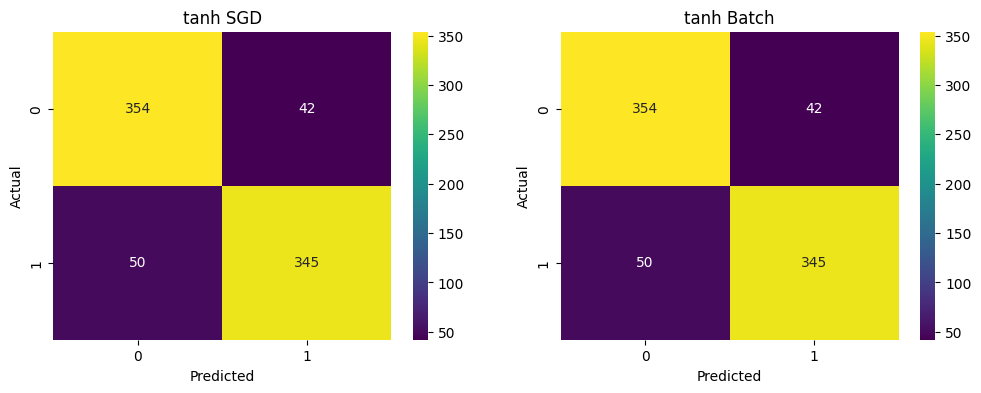


--- Activation: sign ---

Training SGD...
SGD training time: 1.1860 seconds

Training Mini‑Batch...
Mini‑Batch training time: 0.4529 seconds

SGD:

── sign SGD ──
Confusion matrix:
[[284 112]
 [ 12 383]]
Accuracy:       0.843236409608091
Recall:         0.9696202531645569
Specificity:    0.7171717171717171

Batch:

── sign Batch ──
Confusion matrix:
[[274 122]
 [  0 395]]
Accuracy:       0.8457648546144121
Recall:         1.0
Specificity:    0.6919191919191919


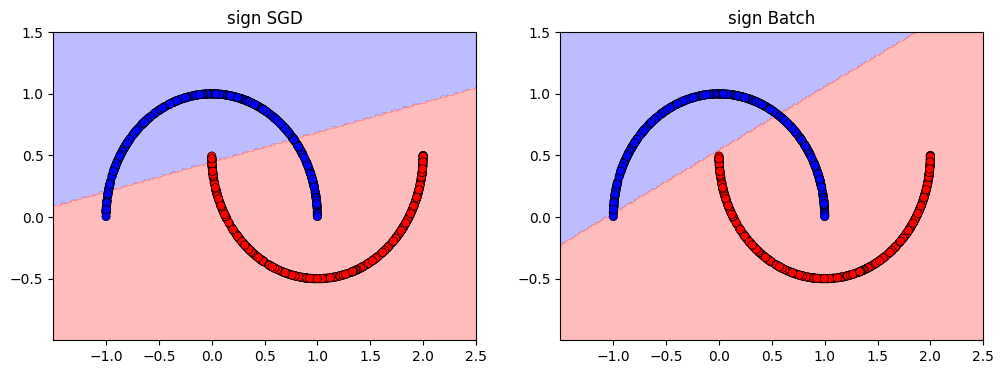

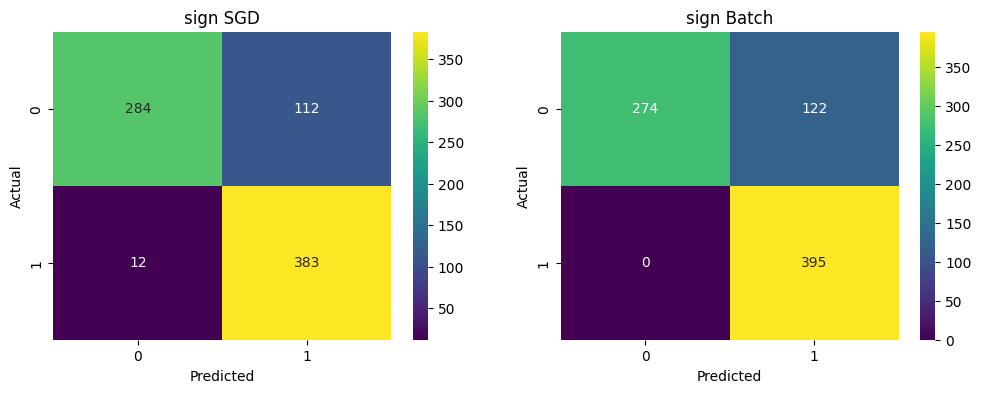


--- Activation: sin ---

Training SGD...
SGD training time: 1.1943 seconds

Training Mini‑Batch...
Mini‑Batch training time: 0.5812 seconds

SGD:

── sin SGD ──
Confusion matrix:
[[354  42]
 [ 50 345]]
Accuracy:       0.8836915297092288
Recall:         0.8734177215189873
Specificity:    0.8939393939393939

Batch:

── sin Batch ──
Confusion matrix:
[[353  43]
 [ 50 345]]
Accuracy:       0.8824273072060683
Recall:         0.8734177215189873
Specificity:    0.8914141414141414


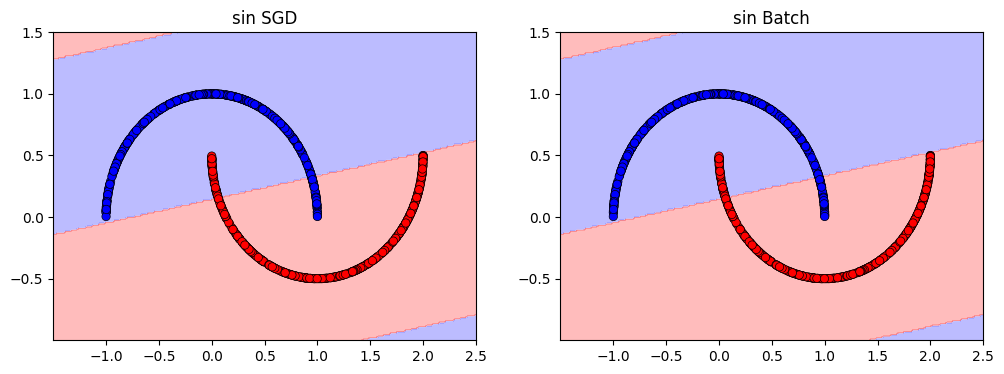

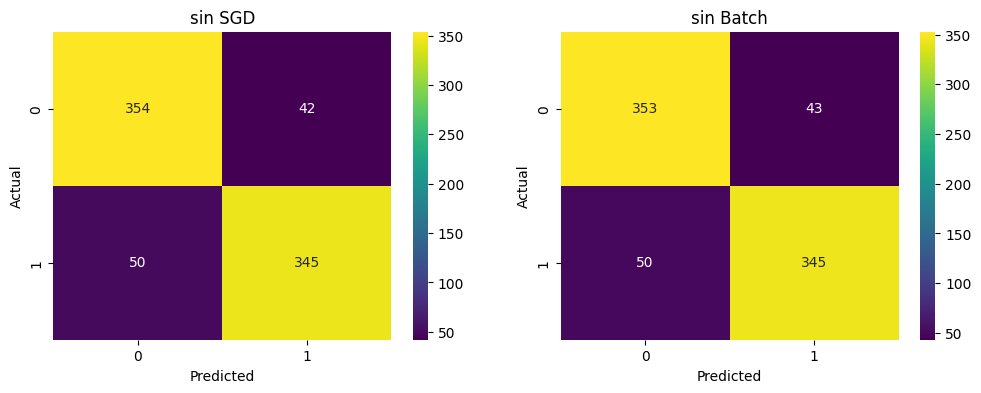


--- Activation: relu ---

Training SGD...
SGD training time: 2.0909 seconds

Training Mini‑Batch...
Mini‑Batch training time: 1.3162 seconds

SGD:

── relu SGD ──
Confusion matrix:
[[396   0]
 [395   0]]
Accuracy:       0.5006321112515802
Recall:         0.0
Specificity:    1.0

Batch:

── relu Batch ──
Confusion matrix:
[[396   0]
 [395   0]]
Accuracy:       0.5006321112515802
Recall:         0.0
Specificity:    1.0


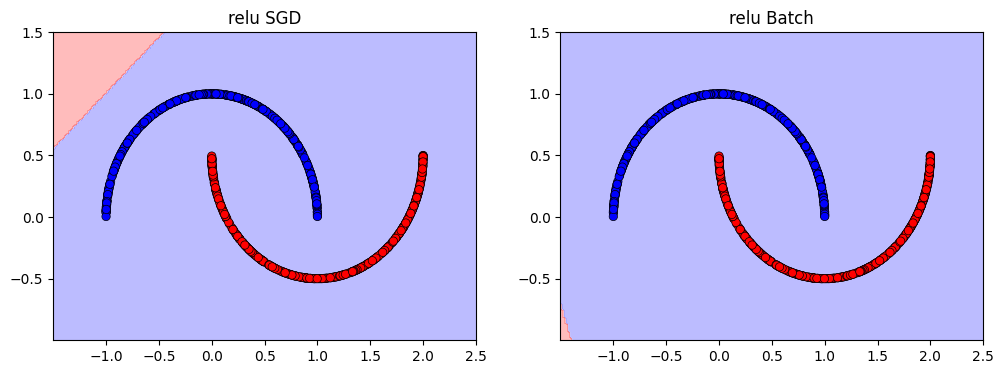

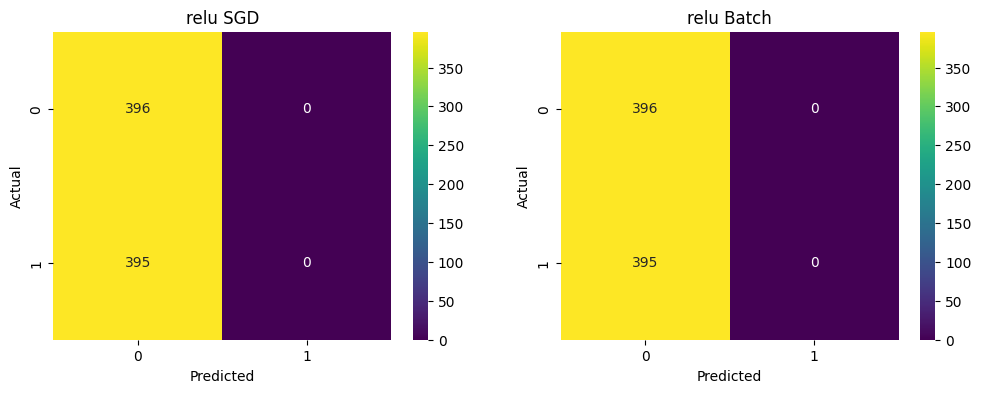


--- Activation: leaky_relu ---

Training SGD...
SGD training time: 2.1085 seconds

Training Mini‑Batch...
Mini‑Batch training time: 1.4124 seconds

SGD:

── leaky_relu SGD ──
Confusion matrix:
[[356  40]
 [ 55 340]]
Accuracy:       0.8798988621997471
Recall:         0.8607594936708861
Specificity:    0.898989898989899

Batch:

── leaky_relu Batch ──
Confusion matrix:
[[357  39]
 [ 55 340]]
Accuracy:       0.8811630847029077
Recall:         0.8607594936708861
Specificity:    0.9015151515151515


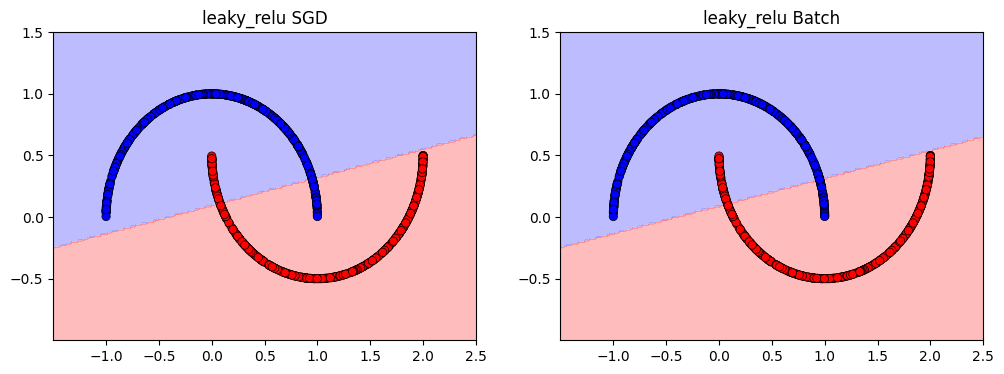

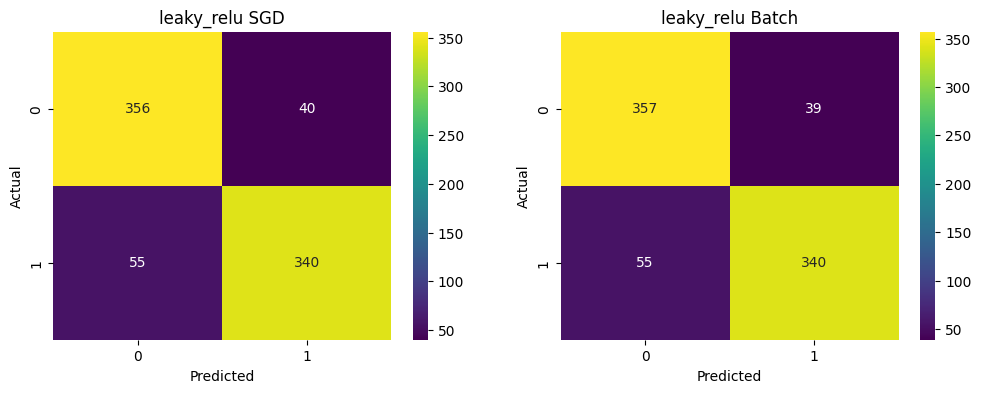

In [94]:
run_experiment_block(X_moons, y_moons, "MOONS DATASET")